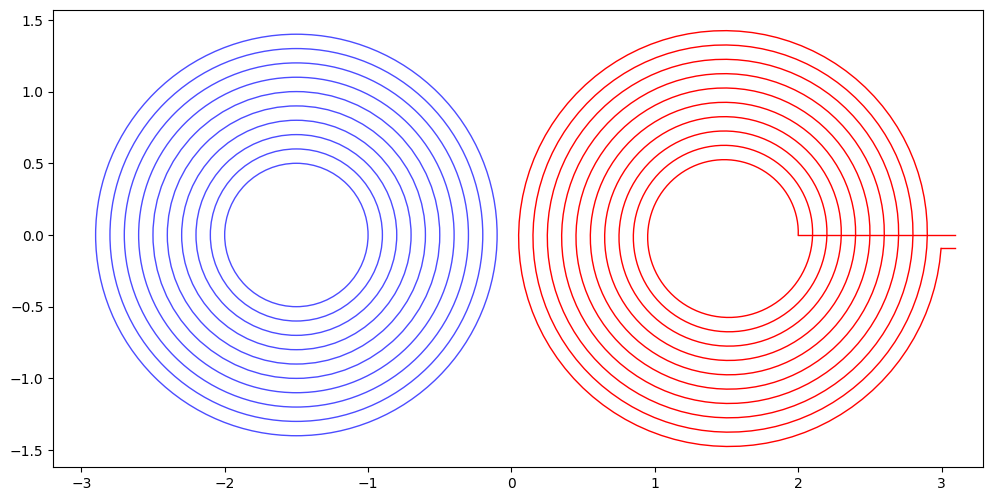

In [15]:
'''
Optimization of magnetic configuration created by two spirals.
'''
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.lines as lines
from dataclasses import dataclass
from scipy.optimize import minimize
import scipy.integrate as integrate
from itertools import combinations
import numpy as np


def spiral_demo():
    '''
    A spiral is modeled by a family of concentric circles.  This
    looks good, because the mean radial current due to the converging
    spiral is compensated by the outgoing straight wire in the opposite
    direction.
    '''
    fig = plt.figure(figsize=(12,8))
    ax  = fig.add_subplot(1, 1, 1)
    for i in range(10):
        ax.add_patch(Circle((-1.5, 0), 0.5+0.1*i, lw=1, alpha=0.7, facecolor='none', edgecolor='blue'))
    tt = np.linspace(0, 20*np.pi, 1000, endpoint=False)
    rr = 0.5 + 1.0*tt/(20*np.pi)
    xx = 1.5 + rr*np.cos(tt)
    yy = 0.0 + rr*np.sin(tt)
    ax.plot(xx, yy, color='red', lw=1)
    ax.add_artist(lines.Line2D([xx[0], xx[-1]+0.1], [yy[0], 0], linewidth=1, color='red'))
    ax.add_artist(lines.Line2D([xx[-1], xx[-1]+0.1], [yy[-1], yy[-1]], linewidth=1, color='red'))
    ax.set_aspect('equal')

spiral_demo()

In [28]:
@dataclass
class Spirals:
    x1: float = -1.0    # x-location of center at y=0
    x2: float =  1.0
    z1: float =  0.0    # z-height of the spirals
    z2: float = -0.01
    a1: float =  0.2    # min radius
    a2: float =  0.3
    b1: float =  1.0    # max radius
    b2: float =  2.0
    Ir: float = -1.0 # I2/I1
    n1: int   = 10
    n2: int   = 10
    # maybe: excentricities (gradual shifts of centers along x)
    def r1(i: int): return a1 + (b1 - a1)*i/(n1 - 1)
    def r2(i: int): return a2 + (b2 - a2)*i/(n2 - 1)
    def __str__(self): # make Params object printable
        n = 4 # precision
        return \
        f'x({round(self.x1,n)},{round(self.x2,n)}), ' + \
        f'z({round(self.z1,n)},{round(self.z2,n)}), ' + \
        f'a({round(self.a1,n)},{round(self.a2,n)}), ' + \
        f'b({round(self.b1,n)},{round(self.b2,n)}), ' + \
        f'n({n1},{n2}), ' + \
        f'Ir{round(self.Ir,n)}'

@dataclass
class SpiralsBounds:
    '''
    Acceptable (min, max) for each param above
    '''
    x1 = (-3, 3)
    x2 = (-3, 3)
    z1 = (-0.2, 0)
    z2 = (-0.2, 0)
    a1 = (0.2, 1)
    a2 = (0.2, 1)
    b1 = (1, 3)
    b2 = (1, 3)
    Ir = (-2, -0.5)

def dB(x, y, z, a, t):
    '''
    Magnetic field at (x, y, z) of infinitesimal piece of loop with unit current
    lying in (x,y) plane with the center at the origin and radius a.
    The loop is defined parametrically as x=a*cos(t), y=a*sin(t), z=0
    '''
    cos, sin = np.cos(t), np.sin(t)
    D2 = (x - a*cos)**2 + (y - a*sin)**2 + z**2
    D3 = D2*np.sqrt(D2)
    bx = a*z*cos/D3
    by = a*z*sin/D3
    bz = a*(a - x*cos - y*sin)/D3
    return np.array([bx, by, bz])

def dB_derivs(x, y, z, a, t):
    '''
    Derivatives of infinitesimal B
    '''
    cos, sin = np.cos(t), np.sin(t)
    D2 = (x - a*cos)**2 + (y - a*sin)**2 + z**2
    D1 = np.sqrt(D2)
    D3 = D2*D1
    D5 = D2*D3
    bxx = -3*a*z*cos*(x - a*cos)/D5
    bxz = a*cos/D3*(1 - 3*z*z/D2)
    bzx = -a*cos/D3 - 3*a*(x - a*cos)*(a - x*cos - y*sin)/D5
    bzz = 3*a*z*(x*cos + y*sin - a)/D5
    return np.array([bxx, bxz, bzx, bzz]) # only some of them

def loop_B(x, y, z, a):
    '''
    t-integral of dB over the loop.
    quad_vec returns ([Bx, By, Bz], integration_error), the latter is omitted.
    '''
    return integrate.quad_vec(lambda t: dB(x, y, z, a, t), 0, 2*np.pi)[0]

def loop_B_derivs(x, y, z, a):
    '''
    t-integral of dB_derivs over the loop, integration_error omitted.
    '''
    return integrate.quad_vec(lambda t: dB_derivs(x, y, z, a, t), 0, 2*np.pi)[0]

def add_(lhs, rhs):
    if not lhs:
        lhs = rhs
    else:
        lhs += rhs

def total_B(x, y, z, spirals): # (Bx, By, Bz)
    B1, B2 = None, None
    for i in spirals.n1: add_(B1, loop_B(x - spirals.x1, y, z - spirals.z1, spirals.r1(i))
    for i in spirals.n2: add_(B2, loop_B(x - spirals.x2, y, z - spirals.z2, spirals.r2(i))
    Bx = B1[0] + spirals.Ir*B2[0]
    By = B1[1] + spirals.Ir*B2[1]
    Bz = B1[2] + spirals.Ir*B2[2]
    return np.array([Bx, By, Bz])

def total_B_derivs(x, y, z, x1, x2, z1, z2, a1, a2, I1, I2):
    D1, D2 = None, None
    for i in spirals.n1: add_(D1, loop_B_derivs(x - spirals.x1, y, z - spirals.z1, spirals.r1(i))
    for i in spirals.n2: add_(D2, loop_B_derivs(x - spirals.x2, y, z - spirals.z2, spirals.r2(i))
    return D1 + spirals.Ir*D2 # (Bxx, Bxz, Bzx, Bzz)

def compute_jac_eigenvector(Bxx, Bxz, Bzx, Bzz):
    C = Bzz - Bxx
    D = np.sqrt(C*C + 4*Bxz*Bzx)
    evec = (C + D, 2*Bxz) # the other one is (C - D, 2*Bxz)
    return evec

def search_params(null_x, null_y, null_z, vars):
    '''
    Minimize square magnetic field at the given point (null_x, 0, null_z) starting with
    default Params and varying one or more specified params ('vars') while holding others constant.
    Variable param names example:  vars = ['x1', 'x2'].
    '''
    pp = Params()  # default/initial params
    bb = ParamBounds()
    def utility(values): # values of vars
        '''
        Squared magnetic field at (null_x, 0, null_z).
        '''
        for var, value in zip(vars, values):
            setattr(pp, var, value) # set pp.<var> = value
        I1, I2 = 1, pp.I_ratio
        return np.sum(np.square(
            total_B(null_x, null_y, null_z, pp.x1, pp.x2, pp.z1, pp.z2, pp.a1, pp.a2, I1, I2)
        ))
    initial_values = [getattr(pp, var) for var in vars] # use default pp.<var> as initial guess
    bounds         = [getattr(bb, var) for var in vars] # extract bounds for the vars
    result = minimize(utility, initial_values, bounds=bounds)
    return result # object containing results of optimization